<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/Specific_plant_dieases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import json
import os

# Upload kaggle.json first
kaggle_credentails = json.load(open("kaggle.json"))

os.environ['KAGGLE_USERNAME'] = kaggle_credentails['username']
os.environ['KAGGLE_KEY'] = kaggle_credentails['key']

# Download dataset
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip plantvillage-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e345153-aed9-4879-a2cc-24f9dc5100e7___UF.GRC_YLCV_Lab 01798_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e37e8ad-3944-4e11-bc10-dd82616274d7___YLCV_NREC 2915_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e382244-fb3a-4caa-af71-05fff25f1c27___UF.GRC_YLCV_Lab 03397_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e3b9886-ce13-49d5-8f80-ccf4e5ddbeac___YLCV_GCREC 5479_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e615038-7a87-446a-a2cd-f76c5c75b6dd___YLCV_GCREC 5144_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e6938d9-1ab0-4728-993c-1069b66ce73b___UF.GRC_YLCV_Lab 02727_final_mas

In [6]:
import os
from collections import defaultdict

dataset_path = "plantvillage dataset"  # Corrected path

plant_counts = defaultdict(int)

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        # Extract plant name (before ___)
        plant_name = folder.split("___")[0]

        num_images = len(os.listdir(folder_path))
        plant_counts[plant_name] += num_images

# Print results
print("🌿 Plant-wise Image Counts:\n")
for plant, count in plant_counts.items():
    print(f"{plant} → {count} images")

print("\nTotal Plants:", len(plant_counts))

🌿 Plant-wise Image Counts:

segmented → 38 images
color → 38 images
grayscale → 38 images

Total Plants: 3


In [7]:
import os
from collections import defaultdict
dataset_path = "plantvillage dataset/color"  # Corrected path

plant_counts = defaultdict(int)

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        # Extract plant name (before ___)
        plant_name = folder.split("___")[0]

        num_images = len(os.listdir(folder_path))
        plant_counts[plant_name] += num_images

# Print results
print("🌿 Plant-wise Image Counts:\n")
for plant, count in plant_counts.items():
    print(f"{plant} → {count} images")

print("\nTotal Plants:", len(plant_counts))

🌿 Plant-wise Image Counts:

Cherry_(including_sour) → 1906 images
Peach → 2657 images
Apple → 3171 images
Potato → 2152 images
Strawberry → 1565 images
Blueberry → 1502 images
Tomato → 18160 images
Orange → 5507 images
Grape → 4062 images
Pepper,_bell → 2475 images
Corn_(maize) → 3852 images
Squash → 1835 images
Raspberry → 371 images
Soybean → 5090 images

Total Plants: 14


In [8]:
import os

apple_classes = [cls for cls in os.listdir(dataset_path) if "apple" in cls.lower()]

print("Apple classes:")
for cls in apple_classes:
    print(cls)

Apple classes:
Apple___Cedar_apple_rust
Apple___healthy
Apple___Black_rot
Apple___Apple_scab


In [9]:
for cls in apple_classes:
    path = os.path.join(dataset_path, cls)
    print(f"{cls} → {len(os.listdir(path))} images")

Apple___Cedar_apple_rust → 275 images
Apple___healthy → 1645 images
Apple___Black_rot → 621 images
Apple___Apple_scab → 630 images


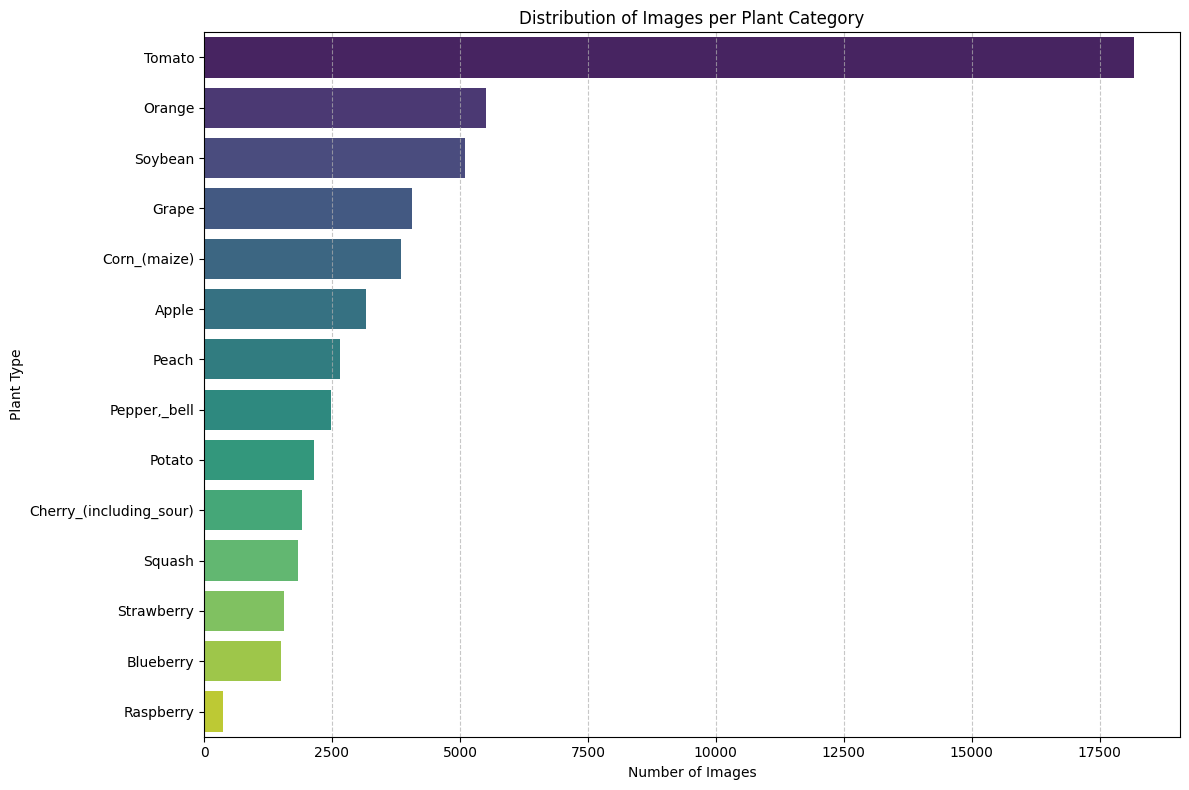

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert plant_counts dictionary to a DataFrame for plotting
plant_counts_df = pd.DataFrame(plant_counts.items(), columns=['Plant', 'Image Count'])

# Sort the DataFrame by image count for better visualization
plant_counts_df = plant_counts_df.sort_values(by='Image Count', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Image Count', y='Plant', hue='Plant', data=plant_counts_df, palette='viridis', legend=False)
plt.title('Distribution of Images per Plant Category')
plt.xlabel('Number of Images')
plt.ylabel('Plant Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Tomato

In [11]:
import os

Tomato_classes = [cls for cls in os.listdir(dataset_path) if "tomato" in cls.lower()]

print("Tomato classes:")
for cls in Tomato_classes:
    print(cls)

Tomato classes:
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Bacterial_spot
Tomato___Septoria_leaf_spot
Tomato___Late_blight
Tomato___Target_Spot
Tomato___healthy
Tomato___Early_blight
Tomato___Leaf_Mold
Tomato___Tomato_mosaic_virus


### Tomato Classes Image Counts

In [12]:
tomato_data = []
for cls in Tomato_classes:
    path = os.path.join(dataset_path, cls)
    tomato_data.append({'Class': cls, 'Image Count': len(os.listdir(path))})

tomato_df = pd.DataFrame(tomato_data)
tomato_df = tomato_df.sort_values(by='Image Count', ascending=False)

display(tomato_df)

,Class,Image Count
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
2,Tomato___Bacterial_spot,2127
4,Tomato___Late_blight,1909
3,Tomato___Septoria_leaf_spot,1771
1,Tomato___Spider_mites Two-spotted_spider_mite,1676
6,Tomato___healthy,1591
5,Tomato___Target_Spot,1404
7,Tomato___Early_blight,1000
8,Tomato___Leaf_Mold,952
9,Tomato___Tomato_mosaic_virus,373


### Tomato Classes Image Counts Visualization

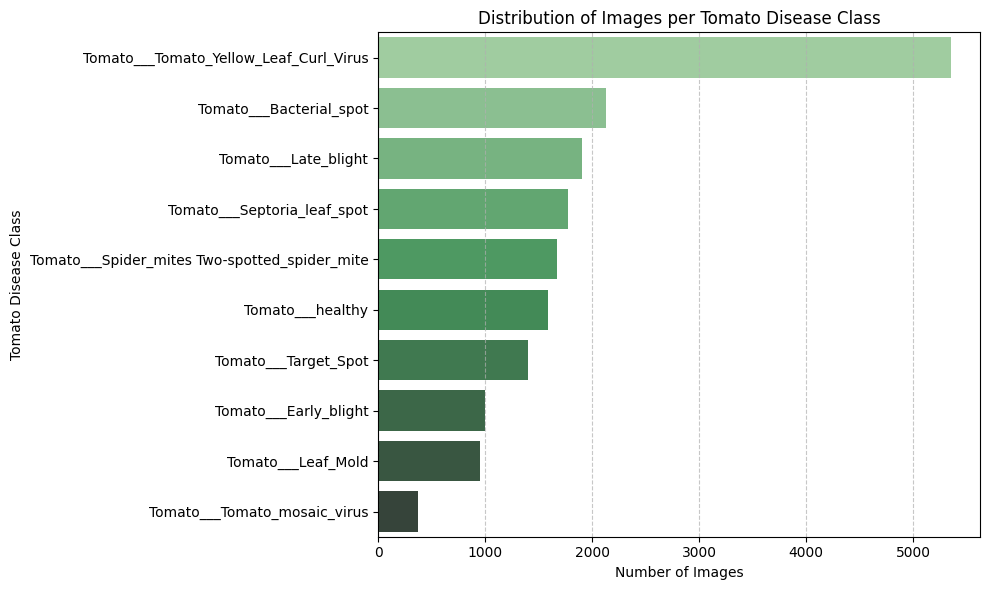

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Image Count', y='Class', hue='Class', data=tomato_df, palette='Greens_d', legend=False)
plt.title('Distribution of Images per Tomato Disease Class')
plt.xlabel('Number of Images')
plt.ylabel('Tomato Disease Class')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Image Preprocessing on Tomato plants

#🍅 1. Tomato Yellow Leaf Curl Virus

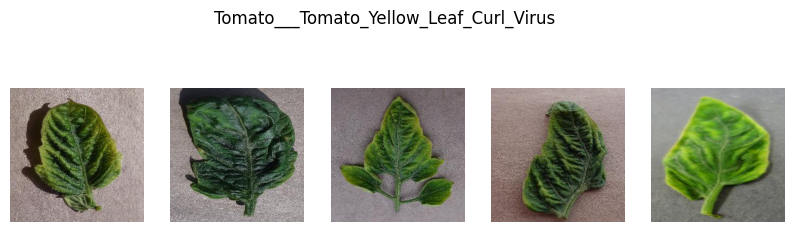

In [14]:
import os, cv2, matplotlib.pyplot as plt, random

cls = "Tomato___Tomato_Yellow_Leaf_Curl_Virus"
path = os.path.join(dataset_path, cls)

imgs = random.sample(os.listdir(path), 5)

plt.figure(figsize=(10,3))
for i, img_name in enumerate(imgs):
    img = cv2.imread(os.path.join(path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(cls)
plt.show()

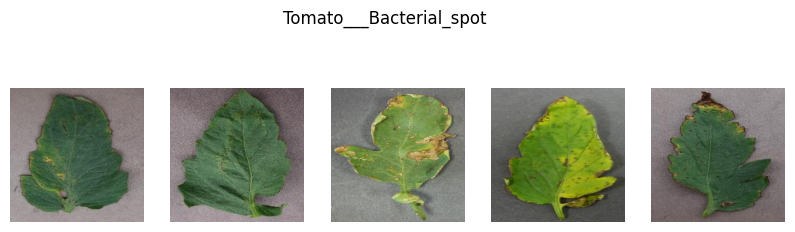

In [15]:
import os, cv2, matplotlib.pyplot as plt, random

cls = "Tomato___Bacterial_spot"
path = os.path.join(dataset_path, cls)

imgs = random.sample(os.listdir(path), 5)

plt.figure(figsize=(10,3))
for i, img_name in enumerate(imgs):
    img = cv2.imread(os.path.join(path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(cls)
plt.show()

#🌧️ 3. Late Blight

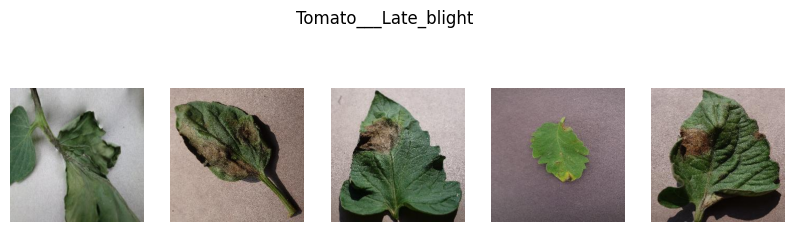

In [16]:
import os, cv2, matplotlib.pyplot as plt, random

cls = "Tomato___Late_blight"
path = os.path.join(dataset_path, cls)

imgs = random.sample(os.listdir(path), 5)

plt.figure(figsize=(10,3))
for i, img_name in enumerate(imgs):
    img = cv2.imread(os.path.join(path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(cls)
plt.show()

#Tomato___healthy

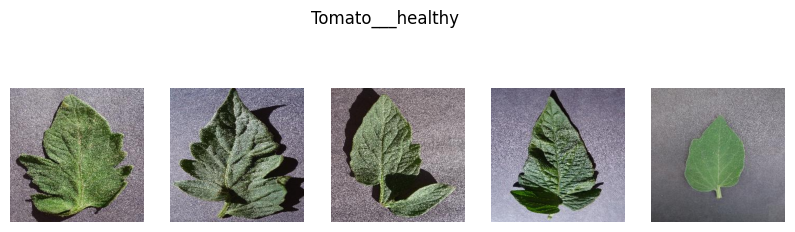

In [17]:
import os, cv2, matplotlib.pyplot as plt, random

cls = "Tomato___healthy"
path = os.path.join(dataset_path, cls)

imgs = random.sample(os.listdir(path), 5)

plt.figure(figsize=(10,3))
for i, img_name in enumerate(imgs):
    img = cv2.imread(os.path.join(path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(cls)
plt.show()

#Data Augmentation

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,              # your actual dataset path
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


#Separate the Tomato Dataset from the folder

In [20]:
import os

os.makedirs("dataset/train", exist_ok=True)
os.makedirs("dataset/val", exist_ok=True)

In [21]:
import shutil
import random

for cls in Tomato_classes:
    src = os.path.join(dataset_path, cls)

    images = os.listdir(src)
    random.shuffle(images)

    split = int(0.8 * len(images))

    train_imgs = images[:split]
    val_imgs = images[split:]

    os.makedirs(f"dataset/train/{cls}", exist_ok=True)
    os.makedirs(f"dataset/val/{cls}", exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(src, img), f"dataset/train/{cls}")

    for img in val_imgs:
        shutil.copy(os.path.join(src, img), f"dataset/val/{cls}")

In [22]:
train_data = train_gen.flow_from_directory(
    "dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = train_gen.flow_from_directory(
    "dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 14523 images belonging to 10 classes.
Found 3637 images belonging to 10 classes.


In [23]:
print(train_data.class_indices)

{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


#Class Distribution (Bar Chart)

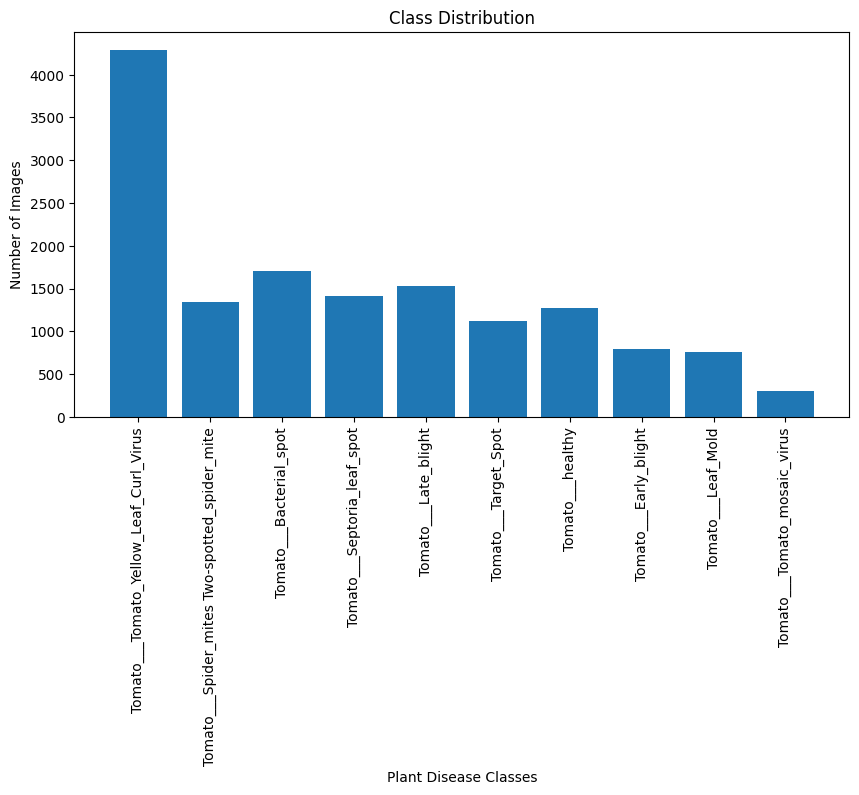

In [31]:
import os
import matplotlib.pyplot as plt

train_dir = "dataset/train"

classes = os.listdir(train_dir)
counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]

plt.figure(figsize=(10,5))
plt.bar(classes, counts)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Plant Disease Classes")
plt.ylabel("Number of Images")
plt.show()

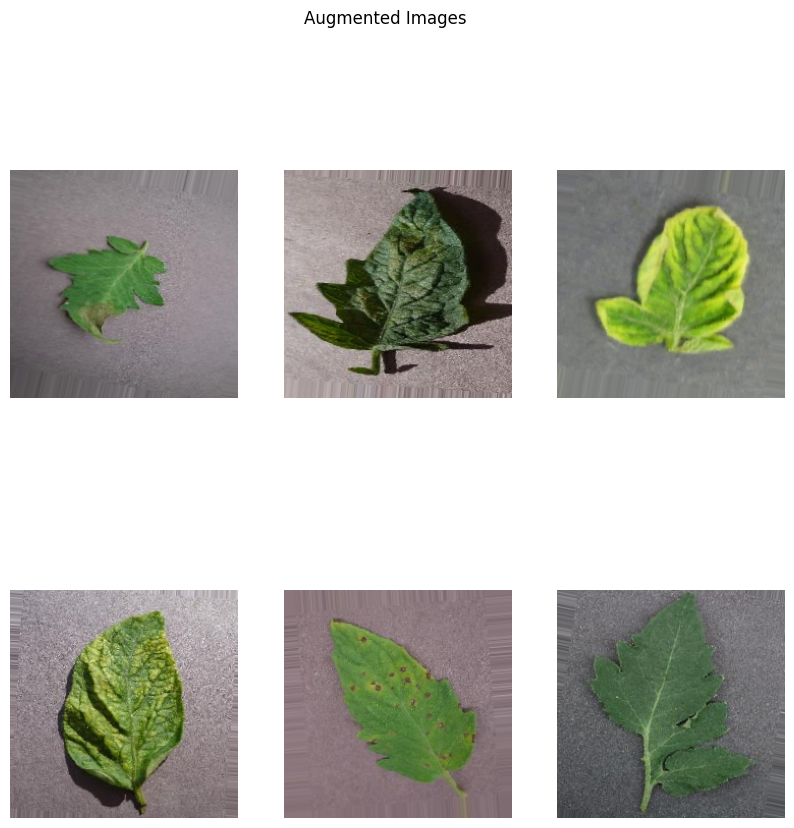

In [33]:
aug_images, _ = next(train_data)

plt.figure(figsize=(10,10))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(aug_images[i])
    plt.axis('off')

plt.suptitle("Augmented Images")
plt.show()

#Build Model (MobileNetV2)

In [24]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
115/454 ━━━━━━━━━━━━━━━━━━━━ 2:13 395ms/step - accuracy: 0.5392 - loss: 1.4185

KeyboardInterrupt: 

#Create Model Functions

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def build_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        MaxPooling2D(),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

#MobileNetV2

In [35]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

def build_mobilenet():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    output = Dense(10, activation='softmax')(x)

    return tf.keras.Model(inputs=base.input, outputs=output)

#ResNet50

In [36]:
from tensorflow.keras.applications import ResNet50

def build_resnet():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    output = Dense(10, activation='softmax')(x)

    return tf.keras.Model(inputs=base.input, outputs=output)

#EfficientNetB0

In [37]:
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    output = Dense(10, activation='softmax')(x)

    return tf.keras.Model(inputs=base.input, outputs=output)

#Train All Models

In [39]:
models = {
    "CNN": build_cnn(),
    "MobileNetV2": build_mobilenet(),
    "ResNet50": build_resnet(),
    "EfficientNetB0": build_efficientnet()
}

history_dict = {}
results = {}

for name, model in models.items():
    print(f"Training {name}...")

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=5
    )

    history_dict[name] = history
    loss, acc = model.evaluate(val_data)
    results[name] = acc

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN...
Epoch 1/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 267s 577ms/step - accuracy: 0.6667 - loss: 1.1217 - val_accuracy: 0.7836 - val_loss: 0.6182
Epoch 2/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 224s 493ms/step - accuracy: 0.8279 - loss: 0.4876 - val_accuracy: 0.8537 - val_loss: 0.4184
Epoch 3/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 210s 463ms/step - accuracy: 0.8727 - loss: 0.3817 - val_accuracy: 0.8826 - val_loss: 0.3416
Epoch 4/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 212s 468ms/step - accuracy: 0.8846 - loss: 0.3295 - val_accuracy: 0.8771 - val_loss: 0.3556
Epoch 5/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 213s 470ms/step - accuracy: 0.9026 - loss: 0.2826 - val_accuracy: 0.9095 - val_loss: 0.2610
114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 366ms/step - accuracy: 0.9101 - loss: 0.2583
Training MobileNetV2...
Epoch 1/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 241s 511ms/step - accuracy: 0.7728 - loss: 0.7265 - val_accuracy: 0.8372 - val_loss: 0.4911
Epoch 2/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 207s 457ms/step - accuracy: 0.8692 - loss: 0.4077 - val_a

#Compare Results

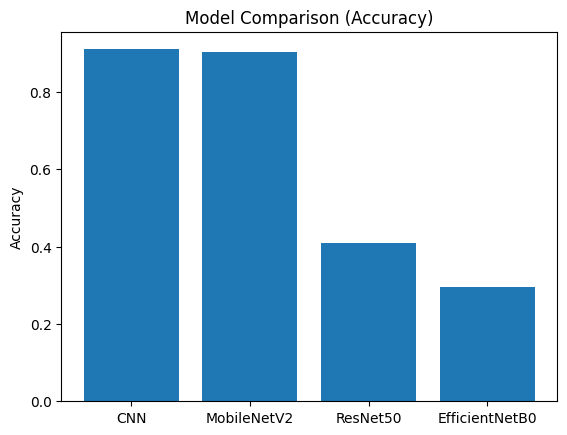

In [40]:
import matplotlib.pyplot as plt

names = list(results.keys())
acc_values = list(results.values())

plt.bar(names, acc_values)
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.show()

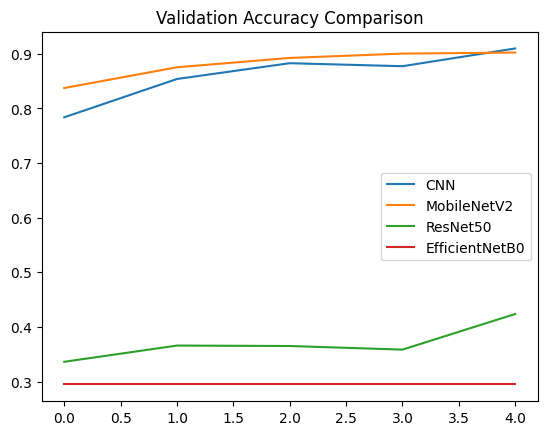

In [41]:
for name, history in history_dict.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()

#Confusion matrix for each model

#Step 1: Create a Reusable Function

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, val_gen, model_name):
    # Predictions
    y_pred = model.predict(val_gen, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # True labels
    y_true = val_gen.classes

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_classes)

    # Plot
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [53]:
for name, model in models.items():
    plot_confusion_matrix(model, val_data, name)

KeyboardInterrupt: 

#Apply for Each Model

In [51]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [52]:
def plot_classification_report(model, val_gen, model_name):
    # Reset generator (IMPORTANT)
    val_gen.reset()

    # Predictions
    y_pred = model.predict(val_gen, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # True labels
    y_true = val_gen.classes

    # Get report as dict
    report = classification_report(y_true, y_pred_classes, output_dict=True)

    # Convert to DataFrame
    df = pd.DataFrame(report).transpose()

    # Remove accuracy row for clean plot
    df = df.iloc[:-1, :]

    # Plot heatmap
    plt.figure(figsize=(10,6))
    sns.heatmap(df.iloc[:, :-1], annot=True, cmap="viridis")
    plt.title(f"Classification Report - {model_name}")
    plt.show()

    return df

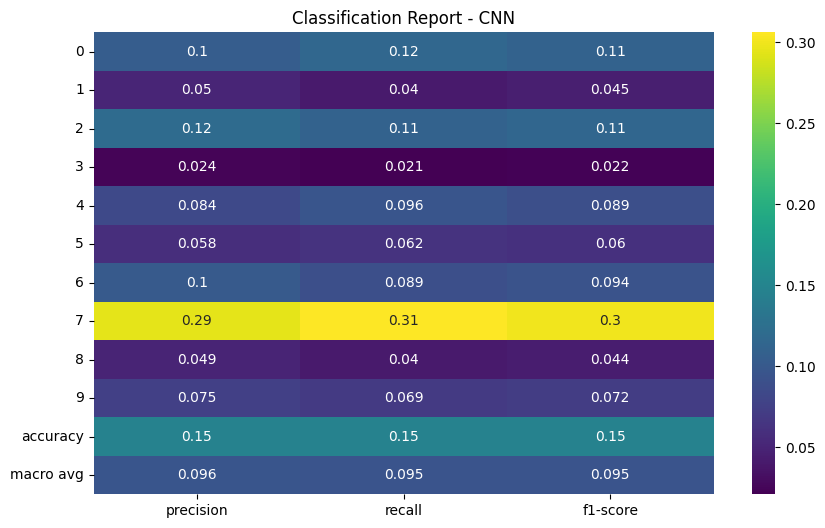

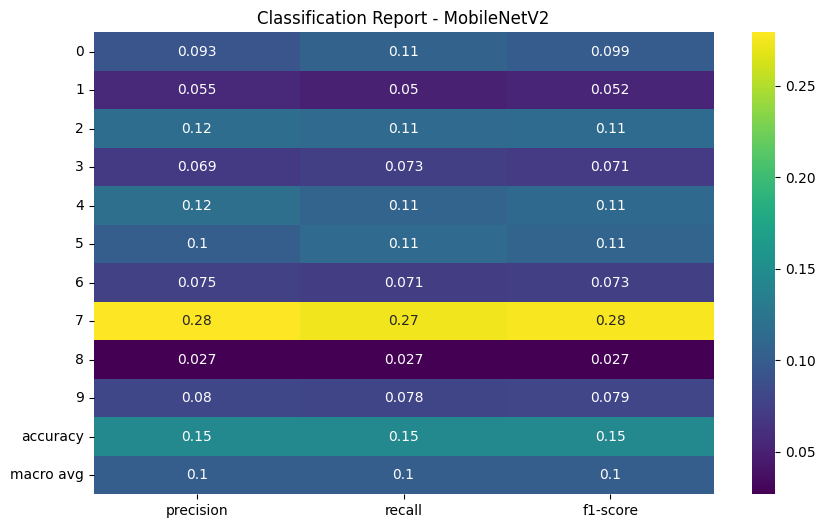

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


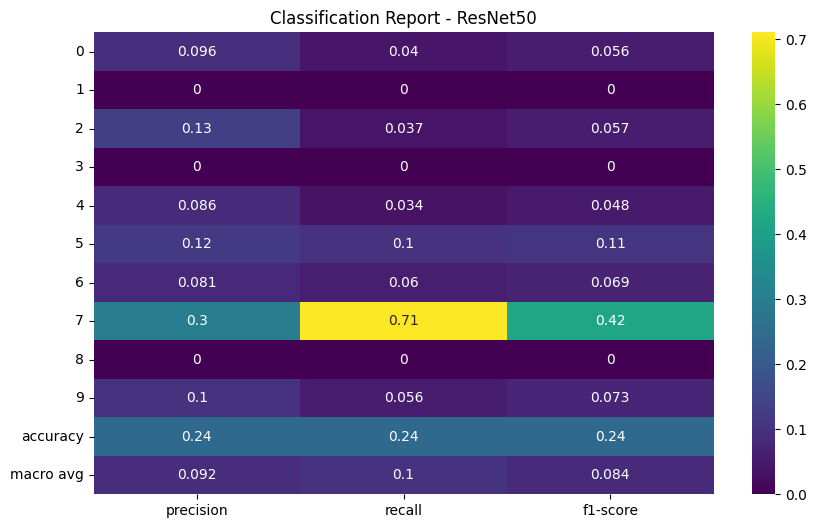

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


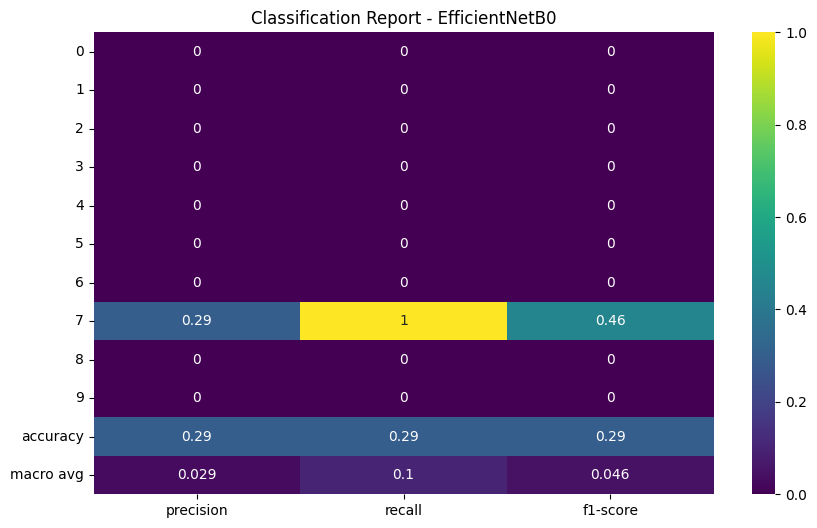

In [56]:
reports = {}

for name, model in models.items():
    df = plot_classification_report(model, val_data, name)
    reports[name] = df

In [57]:
model_names = []
f1_scores = []

for name, df in reports.items():
    f1 = df.loc['weighted avg', 'f1-score']
    model_names.append(name)
    f1_scores.append(f1)

plt.bar(model_names, f1_scores)
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.show()

KeyError: 'weighted avg'

#Add Class Labels

#Save Each Confusion Matrix

In [48]:
class_names = list(train_data.class_indices.keys())